In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
import os

DATASET_PATH = "../data/PlantVillage"

print("Dataset exists:", os.path.exists(DATASET_PATH))
print("Number of classes:", len(os.listdir(DATASET_PATH)))
print("Classes:")
print(os.listdir(DATASET_PATH))

Dataset exists: True
Number of classes: 16
Classes:
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'PlantVillage', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']


In [3]:
nested_path = "../data/PlantVillage/PlantVillage"

print("Nested folder exists:", os.path.exists(nested_path))
print("Number of folders inside it:", len(os.listdir(nested_path)))
print(os.listdir(nested_path))

Nested folder exists: True
Number of folders inside it: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']


In [4]:
import tensorflow as tf

DATASET_PATH = "../data/PlantVillage"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Classes:", train_ds.class_names)

Found 41276 files belonging to 16 classes.
Using 33021 files for training.
Found 41276 files belonging to 16 classes.
Using 8255 files for validation.
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'PlantVillage', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [5]:
import shutil
import os

nested_path = "../data/PlantVillage/PlantVillage"

if os.path.exists(nested_path):
    shutil.rmtree(nested_path)
    print("Duplicate PlantVillage folder removed.")
else:
    print("Folder not found.")

Duplicate PlantVillage folder removed.


In [6]:
import tensorflow as tf

DATASET_PATH = "../data/PlantVillage"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Number of classes:", len(train_ds.class_names))
print("Classes:", train_ds.class_names)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Number of classes: 15
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [7]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

print("Normalization completed.")

Normalization completed.


In [9]:
num_classes = 15

print("Number of classes:", num_classes)

Number of classes: 15


In [10]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(15, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 15)                  │           1,935 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,306,575 (12.61 MB)

 Trainable params: 3,306,575 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


C:\Users\lenov\crop_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


516/516 ━━━━━━━━━━━━━━━━━━━━ 197s 375ms/step - accuracy: 0.4631 - loss: 1.6703 - val_accuracy: 0.7010 - val_loss: 0.9305
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 223s 432ms/step - accuracy: 0.6811 - loss: 0.9504 - val_accuracy: 0.8149 - val_loss: 0.5465
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 192s 372ms/step - accuracy: 0.7592 - loss: 0.7119 - val_accuracy: 0.8231 - val_loss: 0.4939
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 152s 294ms/step - accuracy: 0.8061 - loss: 0.5753 - val_accuracy: 0.8563 - val_loss: 0.4173
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 133s 258ms/step - accuracy: 0.8333 - loss: 0.4912 - val_accuracy: 0.8975 - val_loss: 0.2993
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 140s 271ms/step - accuracy: 0.8663 - loss: 0.3872 - val_accuracy: 0.9045 - val_loss: 0.2980
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 159s 308ms/step - accuracy: 0.8766 - loss: 0.3583 - val_accuracy: 0.9096 - val_loss: 0.2708
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 203s 311ms/step - accuracy: 0.8998 - loss: 0.30

In [13]:
val_loss, val_accuracy = model.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - accuracy: 0.9150 - loss: 0.2496
Validation Loss: 0.24961072206497192
Validation Accuracy: 0.9149503111839294


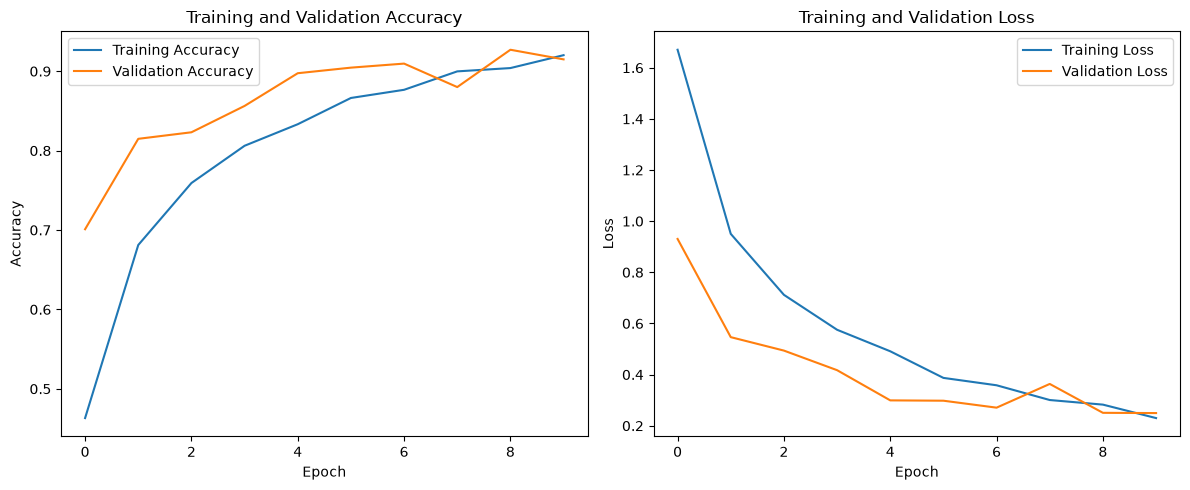

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Class names
class_names = [
    'Pepper__bell___Bacterial_spot',
    'Pepper__bell___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy',
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight',
    'Tomato_Late_blight',
    'Tomato_Leaf_Mold',
    'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite',
    'Tomato__Target_Spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus',
    'Tomato__Tomato_mosaic_virus',
    'Tomato_healthy'
]

# Classification report
print(classification_report(y_true, y_pred, target_names=class_names))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.92      0.93      0.92       200
                     Pepper__bell___healthy       0.99      0.97      0.98       302
                      Potato___Early_blight       0.96      0.93      0.94       189
                       Potato___Late_blight       0.86      0.88      0.87       188
                           Potato___healthy       1.00      0.74      0.85        31
                      Tomato_Bacterial_spot       0.88      0.98      0.93       441
                        Tomato_Early_blight       0.69      0.75      0.72       191
                         Tomato_Late_blight       0.83      0.87      0.85       341
                           Tomato_Leaf_Mold       0.91      0.87      0.89       185
                  Tomato_Septoria_leaf_spot       0.90      0.84      0.87       392
Tomato_Spider_mites_Two_spotted_spider_mite       0.97      0.92

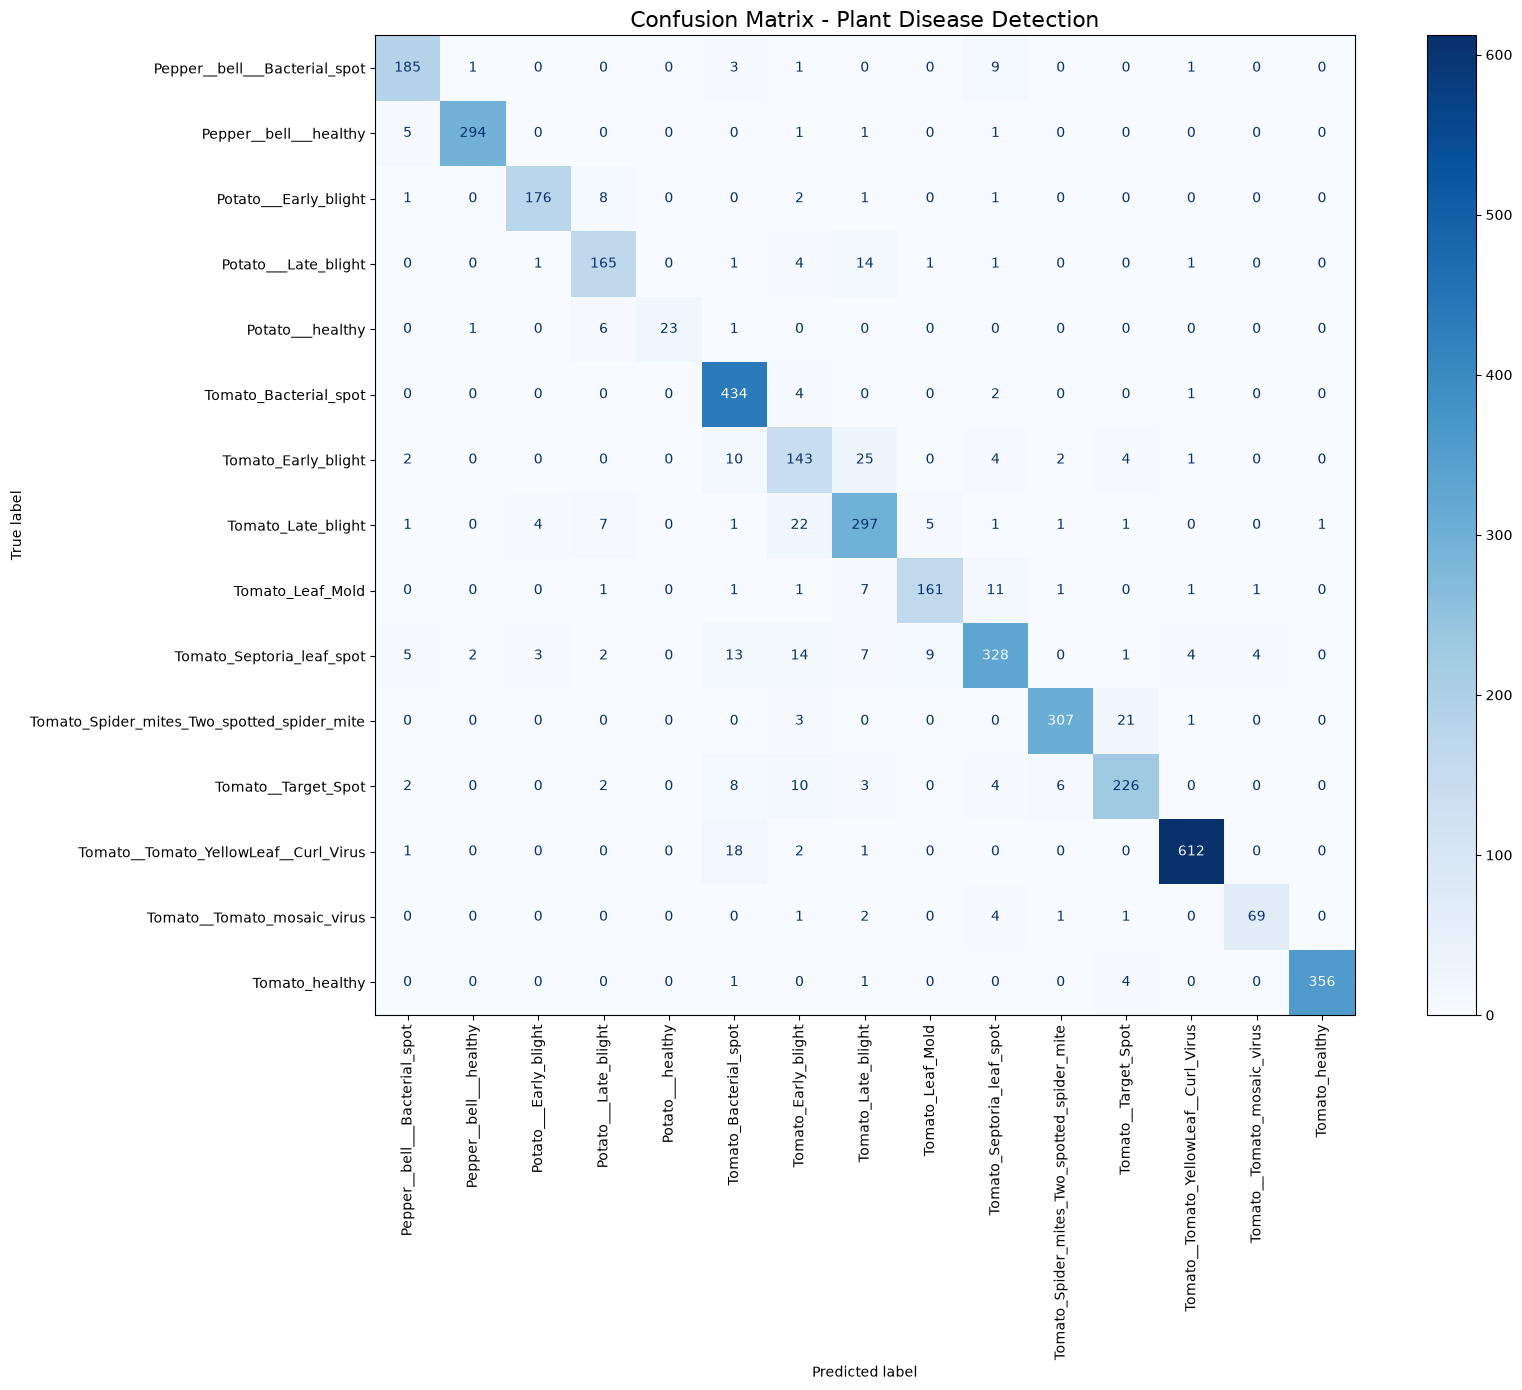

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(18, 14))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Plant Disease Detection", fontsize=16)
plt.tight_layout()
plt.show()

In [20]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

image_path = "../test_images/test.jpg"

img = load_img(image_path, target_size=(128, 128))
img_array = img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Predicted Disease:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")

FileNotFoundError: [Errno 2] No such file or directory: '../test_images/test.jpg'

In [21]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles in test_images:")
print(os.listdir("../test_images"))

Current working directory:
C:\Users\lenov\PE1\Plant disease detection

Files in test_images:


FileNotFoundError: [WinError 3] The system cannot find the path specified: '../test_images'

In [22]:
import os

print(os.listdir("test_images"))

['test.jpg']


In [23]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

image_path = "test_images/test.jpg"

img = load_img(image_path, target_size=(128, 128))
img_array = img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Predicted Disease:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Predicted Disease: Tomato_Late_blight
Confidence: 98.71%


In [24]:
import os

os.makedirs("../model", exist_ok=True)

model.save("../model/plant_disease_model.keras")

print("Model saved successfully.")

Model saved successfully.


In [25]:
import os

model_path = "../model/plant_disease_model.keras"

if os.path.exists(model_path):
    print("Model file found!")
    print("Path:", os.path.abspath(model_path))
    print("Size:", round(os.path.getsize(model_path) / (1024 * 1024), 2), "MB")
else:
    print("Model file not found.")

Model file found!
Path: C:\Users\lenov\PE1\model\plant_disease_model.keras
Size: 37.89 MB


In [26]:
import os

os.makedirs("model", exist_ok=True)

model.save("model/plant_disease_model.keras")

print("Model saved inside project folder.")
print("Path:", os.path.abspath("model/plant_disease_model.keras"))

Model saved inside project folder.
Path: C:\Users\lenov\PE1\Plant disease detection\model\plant_disease_model.keras
